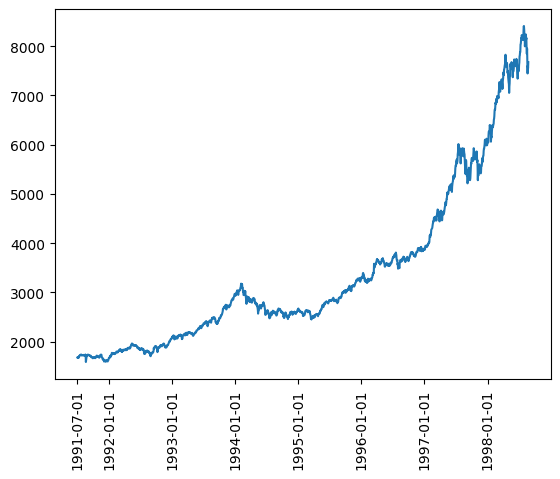

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
dd = pd.read_csv("SMI.csv")
dd["Price"] = dd["dd"] 
plt.plot(dd["dates"],dd["Price"])
yrs = []
curr_yr = " "
for d in dd["dates"]:
    if d[0:4] != curr_yr:
        curr_yr = d[0:4]
        yrs.append(d)
plt.xticks(yrs)
plt.xticks(rotation=90)
plt.show()


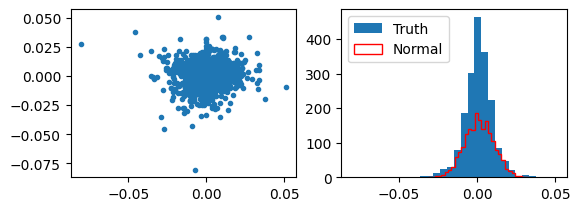

0.0476169648830863


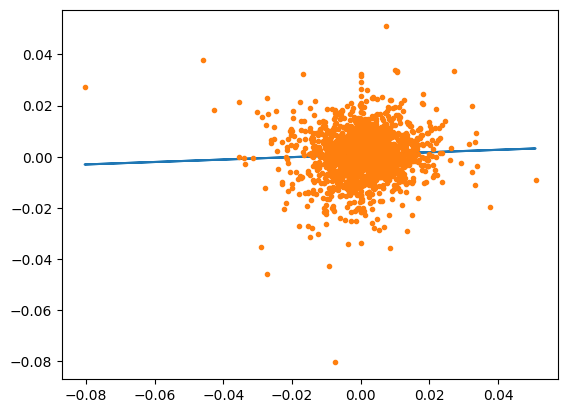

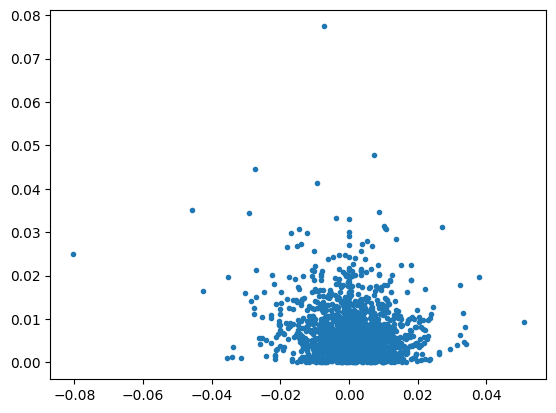

In [24]:
R = (((dd["Price"].shift(-1)-dd["Price"][:-1])/dd["Price"])[:-1])
lag = 1
R_l0 = R[:-lag]
R_l = R[lag:]
plt.subplot(2,2,1)
plt.plot(R_l0,R_l,'.')
plt.subplot(2,2,2)
plt.hist(R,bins=30,label="Truth")
plt.hist(np.random.normal(loc=np.mean(R),scale=np.sqrt(np.var(R)),size=(len(R))),color='r',histtype='step',label="Normal",bins=30)
plt.legend()
plt.show()
import scipy.stats as stat
Cov = np.cov((R_l0),(R_l))
Var = np.var(R_l0)
B_hat = Cov[0][1]/Var
print(B_hat)
alpha_hat = R_l.mean()-B_hat*R_l0.mean()
Y_hat = alpha_hat+B_hat*R_l0
plt.plot(R_l0,Y_hat)
plt.plot(R_l0,R_l,'.')
plt.show()


plt.plot(R_l0,abs(R_l-Y_hat)[1:],'.')
plt.show()
